# Seaborn Intro

In [1]:
import ast
import pandas as pd
import matplotlib.pyplot as plt
from datasets import load_dataset

# Load data
dataset = load_dataset("lukebarousse/data_jobs")
df = dataset["train"].to_pandas()

# Data cleanup
df["job_posted_date"] = pd.to_datetime(df["job_posted_date"])
df["job_skills"] = df["job_skills"].apply(lambda skill: ast.literal_eval(skill)
                                          if pd.notna(skill) else skill)

c:\Users\PC\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
import seaborn as sns

In [3]:
# Only get Data Analyst jobs in the US
df_DA_US = df[(df["job_title_short"] == "Data Analyst") & (df["job_country"] == "United States")].copy()

# Drop NaN values from the "salary_year_avg" column for accurate visualization
df_DA_US = df_DA_US.dropna(subset=["salary_year_avg"])

In [4]:
df_DA_US = df_DA_US.explode("job_skills")

df_DA_US_group = df_DA_US.groupby(by="job_skills")["salary_year_avg"].agg(["count", "median"])
df_DA_top_pay = df_DA_US_group.sort_values(by="median", ascending=False).head(10)
df_DA_skills = df_DA_US_group.sort_values(by="count", ascending=False).head(10).sort_values(by="median", ascending=False).head(10)

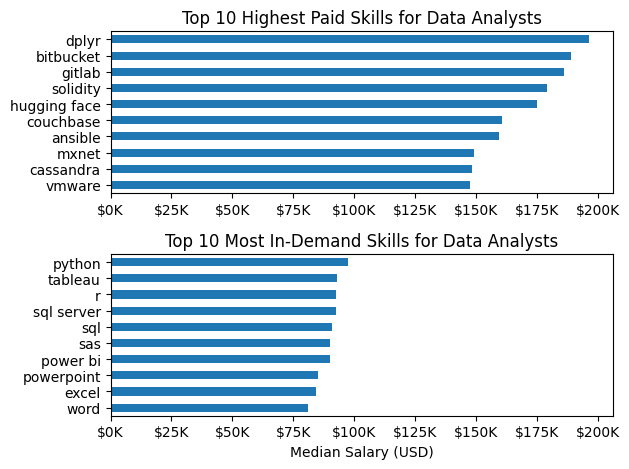

In [7]:
# Using Matplotlib
fig, ax = plt.subplots(2, 1)

df_DA_top_pay.plot(kind="barh", y="median", ax=ax[0], legend=False)
ax[0].set_title("Top 10 Highest Paid Skills for Data Analysts")
ax[0].set_ylabel("")
ax[0].set_xlabel("")
ax[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, pos: f"${int(x / 1000)}K"))

df_DA_skills.plot(kind="barh", y="median", ax=ax[1], legend=False)
ax[1].set_title("Top 10 Most In-Demand Skills for Data Analysts")
ax[1].set_ylabel("")
ax[1].set_xlabel("Median Salary (USD)")
ax[1].set_xlim(ax[0].get_xlim())
ax[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, pos: f"${int(x / 1000)}K"))

ax[0].invert_yaxis()
ax[1].invert_yaxis()

plt.tight_layout()
plt.show()

## Seaborn

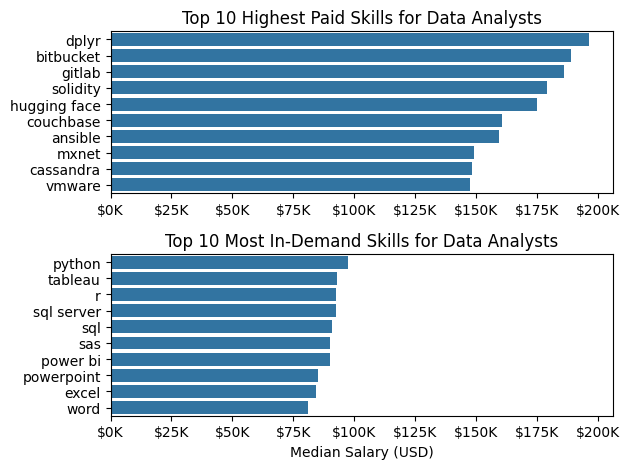

In [15]:
# Using Seaborn
fig, ax = plt.subplots(2, 1)

sns.barplot(data=df_DA_top_pay, x="median", y=df_DA_top_pay.index, ax=ax[0])
ax[0].set_title("Top 10 Highest Paid Skills for Data Analysts")
ax[0].set_ylabel("")
ax[0].set_xlabel("")
ax[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, pos: f"${int(x / 1000)}K"))

sns.barplot(data=df_DA_skills, x="median", y=df_DA_skills.index, ax=ax[1])
ax[1].set_title("Top 10 Most In-Demand Skills for Data Analysts")
ax[1].set_ylabel("")
ax[1].set_xlabel("Median Salary (USD)")
ax[1].set_xlim(ax[0].get_xlim())
ax[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, pos: f"${int(x / 1000)}K"))

# ax[0].invert_yaxis()
# ax[1].invert_yaxis()

plt.tight_layout()
plt.show()

## Hue

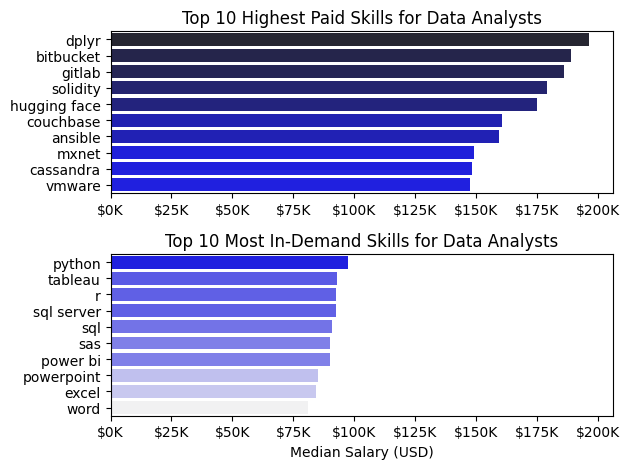

In [16]:
# Using Seaborn
fig, ax = plt.subplots(2, 1)

# _r = reverse color
sns.barplot(data=df_DA_top_pay, x="median", y=df_DA_top_pay.index, ax=ax[0], hue="median", 
            palette="dark:b_r")
ax[0].set_title("Top 10 Highest Paid Skills for Data Analysts")
ax[0].set_ylabel("")
ax[0].set_xlabel("")
ax[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, pos: f"${int(x / 1000)}K"))
ax[0].legend().remove()

sns.barplot(data=df_DA_skills, x="median", y=df_DA_skills.index, ax=ax[1], hue="median", 
            palette="light:b")
ax[1].set_title("Top 10 Most In-Demand Skills for Data Analysts")
ax[1].set_ylabel("")
ax[1].set_xlabel("Median Salary (USD)")
ax[1].set_xlim(ax[0].get_xlim())
ax[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, pos: f"${int(x / 1000)}K"))
ax[1].legend().remove()

# ax[0].invert_yaxis()
# ax[1].invert_yaxis()

plt.tight_layout()
plt.show()

## Theme

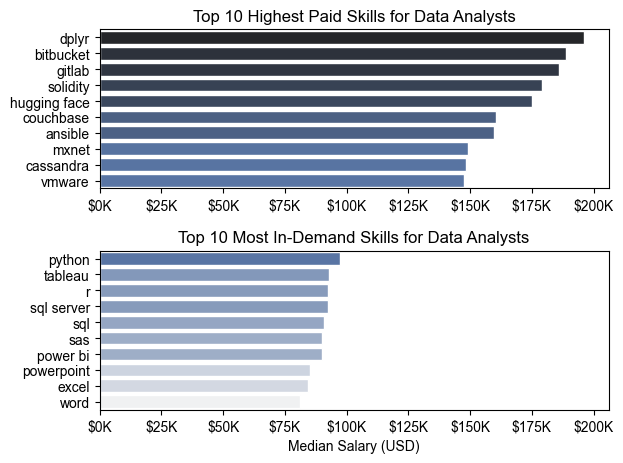

In [17]:
# Using Seaborn
fig, ax = plt.subplots(2, 1)

sns.set_theme(style="ticks")

# _r = reverse color
sns.barplot(data=df_DA_top_pay, x="median", y=df_DA_top_pay.index, ax=ax[0], hue="median", 
            palette="dark:b_r")
ax[0].set_title("Top 10 Highest Paid Skills for Data Analysts")
ax[0].set_ylabel("")
ax[0].set_xlabel("")
ax[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, pos: f"${int(x / 1000)}K"))
ax[0].legend().remove()

sns.barplot(data=df_DA_skills, x="median", y=df_DA_skills.index, ax=ax[1], hue="median", 
            palette="light:b")
ax[1].set_title("Top 10 Most In-Demand Skills for Data Analysts")
ax[1].set_ylabel("")
ax[1].set_xlabel("Median Salary (USD)")
ax[1].set_xlim(ax[0].get_xlim())
ax[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, pos: f"${int(x / 1000)}K"))
ax[1].legend().remove()

# ax[0].invert_yaxis()
# ax[1].invert_yaxis()

plt.tight_layout()
plt.show()

(0.0, 250000.0)

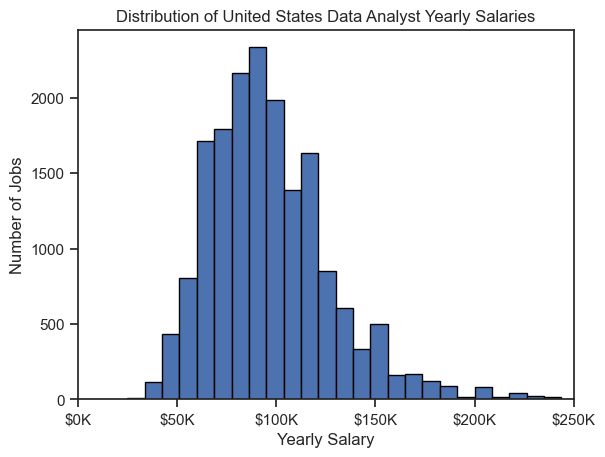

In [25]:
# Using Matplotlib
fig, ax = plt.subplots()

df_DA_US["salary_year_avg"].plot(kind="hist", bins=40, edgecolor="black", ax=ax)

ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"${int(x / 1000)}K"))
plt.title("Distribution of United States Data Analyst Yearly Salaries")
plt.xlabel("Yearly Salary")
plt.ylabel("Number of Jobs")
plt.xlim(0, 250000)

(0.0, 250000.0)

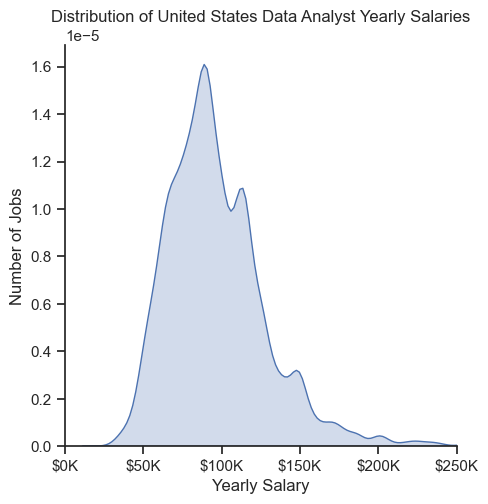

In [26]:
# Using Seaborn
sns.displot(df_DA_US["salary_year_avg"], kind="kde", fill=True)

ax = plt.gca()
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"${int(x / 1000)}K"))

plt.title("Distribution of United States Data Analyst Yearly Salaries")
plt.xlabel("Yearly Salary")
plt.ylabel("Number of Jobs")
plt.xlim(0, 250000)

In [27]:
# Only get certain US jobs
job_titles = ["Data Analyst", "Data Engineer", "Data Scientist"]

df_US = df[(df["job_title_short"].isin(job_titles)) & (df["job_country"] == "United States")].copy()

# Drop NaN values from the column for plotting
df_US = df_US.dropna(subset=["salary_year_avg"])

job_list = [df_US[df_US["job_title_short"] == job_title]["salary_year_avg"] 
            for job_title in job_titles]

C:\Users\PC\AppData\Local\Temp\ipykernel_7640\3701661695.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(job_list, labels=job_titles, vert=False)


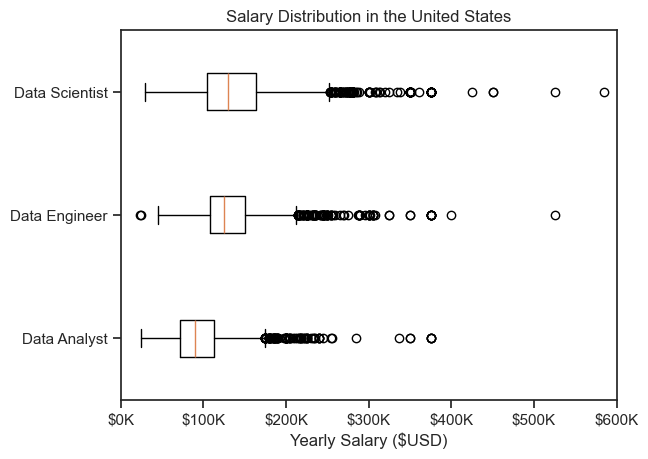

In [28]:
# Using Matplotlib
fig, ax = plt.subplots()

def format_salary(x, pos):
    return f"${int(x / 1000)}K"

plt.boxplot(job_list, labels=job_titles, vert=False)

ax.xaxis.set_major_formatter(plt.FuncFormatter(format_salary))

plt.title("Salary Distribution in the United States")
plt.xlabel("Yearly Salary ($USD)")
plt.xlim(0, 600000)
plt.show()

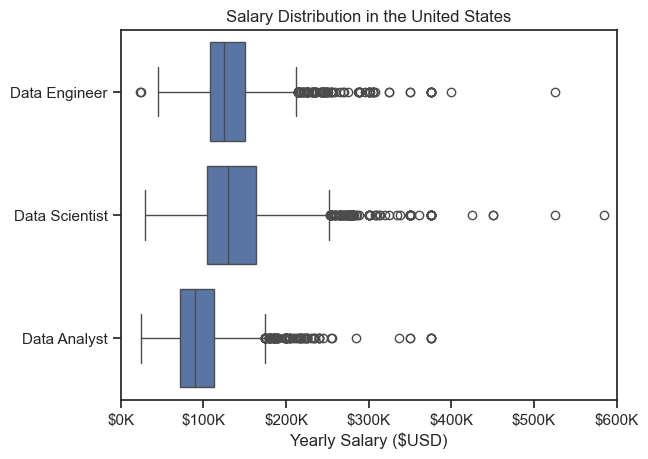

In [30]:
# Using Seaborn
sns.boxplot(data=df_US, x="salary_year_avg", y="job_title_short")

def format_salary(x, pos):
    return f"${int(x / 1000)}K"

ax = plt.gca()
ax.xaxis.set_major_formatter(plt.FuncFormatter(format_salary))

plt.title("Salary Distribution in the United States")
plt.xlabel("Yearly Salary ($USD)")
plt.ylabel("")
plt.xlim(0, 600000)
plt.show()